# Kernel GIS Test Project

Тестове завдання: читання контурів полів, пошук і завантаження супутникових знімків Sentinel-2 L2A за липень 2026, розрахунок NDVI по кожному полю, збереження результатів у SQLite.

## Теоретична частина: Sentinel-2 та NDVI

**Sentinel-2** — програма супутникового спостереження Землі Європейського космічного 
агентства (ESA), частина системи Copernicus. Складається з пари супутників (Sentinel-2A 
і Sentinel-2B, з 2024 року — і Sentinel-2C), які разом облітають всю поверхню Землі з 
періодичністю приблизно 5 днів, знімаючи мультиспектральні знімки з просторовою роздільною 
здатністю від 10 до 60 метрів залежно від каналу.

**Рівень обробки L2A** означає, що дані вже пройшли атмосферну корекцію — усунено спотворення, 
внесені розсіюванням світла в атмосфері (аерозолі, водяна пара), тому значення відбиття 
відповідають реальній поверхні Землі, а не "сирому" сигналу з космосу. Це стандарт для 
подальшого кількісного аналізу (зокрема, для NDVI).

**NDVI (Normalized Difference Vegetation Index)** — нормалізований різницевий вегетаційний 
індекс, один з найпоширеніших показників стану рослинності, розраховується за формулою:

$$NDVI = \\frac{NIR - Red}{NIR + Red}$$

де:
- **Red** (канал B04, ~665 нм) — видиме червоне світло, яке хлорофіл активно поглинає 
  для фотосинтезу; здорова рослинність відбиває його мало
- **NIR** (канал B08, ~842 нм) — ближнє інфрачервоне світло, яке клітинна структура 
  листя сильно відбиває; здорова рослинність відбиває його багато

Значення NDVI лежать у діапазоні від -1 до 1:
- **0.6–0.9** — густа, здорова рослинність в активній вегетації
- **0.2–0.5** — слабка або розріджена рослинність
- **0.0–0.2** — гола земля, стерня, скошені або дозрілі поля
- **< 0** — вода, сніг, хмари, штучні поверхні

У точному землеробстві NDVI використовують для моніторингу стану посівів, раннього виявлення 
проблемних ділянок (нестача вологи, шкідники, нерівномірне внесення добрив) та формування 
карт диференційованого внесення добрив.

In [38]:
import os
os.environ['PROJ_NETWORK'] = 'OFF'

import zipfile
import sqlite3
import time

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import requests
import pystac_client
import planetary_computer
from shapely.geometry import mapping
from rasterstats import zonal_stats

## 1. Контури полів

Читання і візуалізація меж полів з shapefile за допомогою geopandas.

In [39]:
zip_path = "data/fields_1.zip"
extract_path = "data/fields"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

shp_file_path = os.path.join(extract_path, 'fields.shp')
fields = gpd.read_file(shp_file_path, engine='fiona')

print("Кількість полів:", len(fields))
print("CRS:", fields.crs)
print("Колонки:", fields.columns.tolist())
fields.head()

Кількість полів: 16
CRS: EPSG:4326
Колонки: ['field_name', 'Shape__Are', 'Shape__Len', 'geometry']


,field_name,Shape__Are,Shape__Len,geometry
0,90.25.15.36.88.01,0.000245,0.078717,"POLYGON Z ((32.25101 50.65191 -100000, 32.2510..."
1,90.25.15.36.88.03,0.000098,0.052183,"POLYGON Z ((32.21567 50.66786 -100000, 32.2157..."
2,90.25.15.36.88.04,0.000118,0.056758,"POLYGON Z ((32.21525 50.67822 -100000, 32.2153..."
3,90.25.15.36.88.05,0.000035,0.035190,"POLYGON Z ((32.21316 50.6776 -100000, 32.21319..."
4,90.25.15.36.88.02,0.000152,0.060959,"POLYGON Z ((32.23463 50.65556 -100000, 32.2348..."


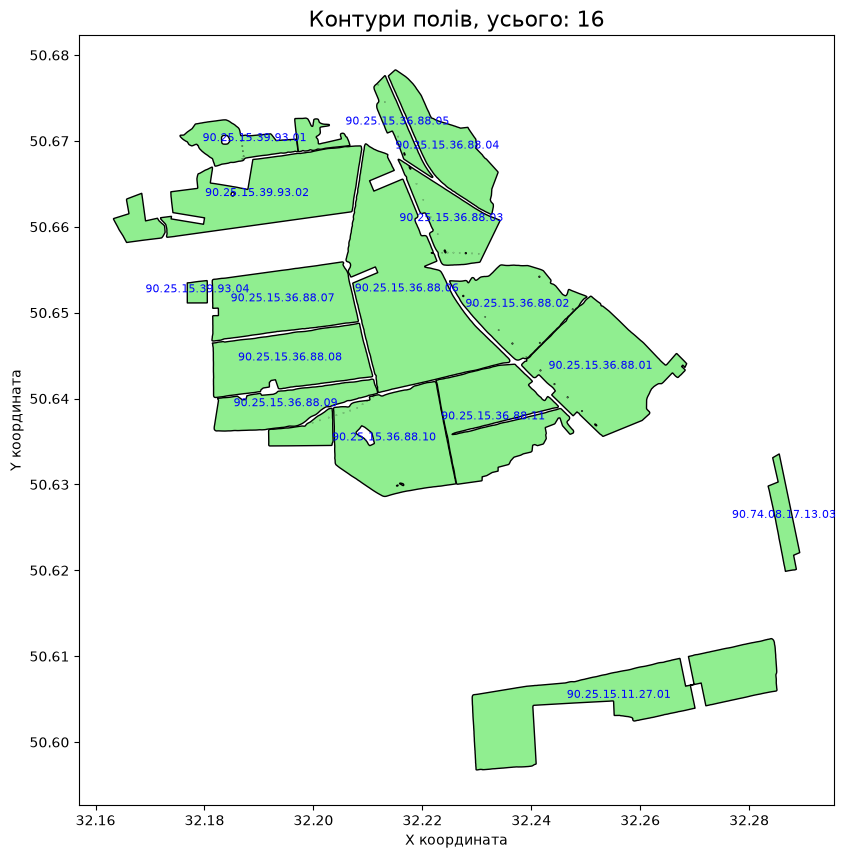

In [40]:
fig, ax = plt.subplots(figsize=(12, 10))
fields.plot(ax=ax, color='lightgreen', edgecolor='black')

for idx, row in fields.iterrows():
    plt.annotate(
        text=row['field_name'],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        horizontalalignment='center', fontsize=8, color='blue'
    )

plt.xlabel('X координата')
plt.ylabel('Y координата')
ax.set_title("Контури полів, усього: {0}".format(len(fields)), fontsize=16)
plt.show()

In [41]:
print("Загальна площа всіх полів:", fields['Shape__Are'].sum())
print("Середня площа поля:", fields['Shape__Are'].mean())
print("Найбільше поле:", fields['Shape__Are'].max())
print("Найменше поле:", fields['Shape__Are'].min())

Загальна площа всіх полів: 0.00264234869
Середня площа поля: 0.000165146793125
Найбільше поле: 0.00040107501
Найменше поле: 9.07466e-06


**Опис результатів.** Прочитано 16 полів з `fields_1.zip`. CRS у файлі не визначений (`None`) — 
система координат встановлюється додатково нижче, через перепроєкцію контурів безпосередньо 
до CRS кожного растрового знімка (UTM), під час розрахунку NDVI.

## 2. Пошук та завантаження Sentinel-2 L2A

Пошук і завантаження виконано через **Microsoft Planetary Computer** (STAC API). Альтернативне 
джерело тих самих даних — офіційний **Copernicus Data Space Ecosystem** (dataspace.copernicus.eu), 
де доступне і ручне завантаження через веб-браузер.

Пошук виконано за bounding box меж полів, а не за точною геометрією контурів — запит з повною 
геометрією перевищував ліміт розміру запиту сервера (помилка 413). Оскільки розмір плитки 
Sentinel-2 (~100×100 км) значно перевищує площу самих полів, це спрощення не впливає на 
результат пошуку.

In [42]:
fields_wgs84 = fields.to_crs(epsg=4326)
bbox = fields_wgs84.total_bounds
print("Межі території полів:", bbox)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

Межі території полів: [32.16329214 50.59675494 32.28929362 50.67827002]


In [43]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2026-07-01/2026-07-31",
    query={"eo:cloud_cover": {"lt": 30}},
)
items = list(search.items())
print(f"Знайдено {len(items)} плиток")
for item in items:
    print(" -", item.id, "|", item.datetime.date(), "| хмарність:", item.properties.get("eo:cloud_cover"))

Знайдено 7 плиток
 - S2A_MSIL2A_20260727T085721_R007_T36UVB_20260727T143400 | 2026-07-27 | хмарність: 12.065183
 - S2B_MSIL2A_20260727T084559_R107_T36UVB_20260727T110455 | 2026-07-27 | хмарність: 9.592289
 - S2C_MSIL2A_20260725T085601_R007_T36UVB_20260725T123212 | 2026-07-25 | хмарність: 27.397984
 - S2A_MSIL2A_20260717T090411_R007_T36UVB_20260717T140714 | 2026-07-17 | хмарність: 2.230918
 - S2B_MSIL2A_20260717T084559_R107_T36UVB_20260717T125252 | 2026-07-17 | хмарність: 2.847742
 - S2C_MSIL2A_20260715T085601_R007_T36UVB_20260715T124308 | 2026-07-15 | хмарність: 22.683007
 - S2C_MSIL2A_20260702T084601_R107_T36UVB_20260702T140813 | 2026-07-02 | хмарність: 8.90253


In [ ]:
def download_with_retry(url, dest_path, max_retries=5):
    if os.path.exists(dest_path):
        return dest_path

    for attempt in range(max_retries):
        try:
            response = requests.get(url, stream=True, timeout=120)
            response.raise_for_status()
            with open(dest_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    f.write(chunk)
            return dest_path
        except Exception as e:
            print(f"  Спроба {attempt + 1} невдала: {e}")
            if os.path.exists(dest_path):
                os.remove(dest_path)
            time.sleep(3)

    raise Exception(f"Не вдалось завантажити {url} після {max_retries} спроб")

In [45]:
os.makedirs("data/sentinel2", exist_ok=True)
downloaded_tiles = []

print("--- Завантаження ---")
for item in items:
    date_str = item.datetime.strftime("%Y%m%d")
    red_path = f"data/sentinel2/{item.id}_B04.tif"
    nir_path = f"data/sentinel2/{item.id}_B08.tif"

    try:
        download_with_retry(item.assets["B04"].href, red_path)
        print(f"Готово Red: {item.id}")
        download_with_retry(item.assets["B08"].href, nir_path)
        print(f"Готово NIR: {item.id}")
        downloaded_tiles.append((item.id, date_str, red_path, nir_path))
    except Exception as e:
        print(f"ПОМИЛКА для {item.id}: {e}")

print(f"\nВсього успішно оброблено плиток: {len(downloaded_tiles)}")

--- Завантаження ---
Готово Red: S2A_MSIL2A_20260727T085721_R007_T36UVB_20260727T143400
Готово NIR: S2A_MSIL2A_20260727T085721_R007_T36UVB_20260727T143400
Готово Red: S2B_MSIL2A_20260727T084559_R107_T36UVB_20260727T110455
Готово NIR: S2B_MSIL2A_20260727T084559_R107_T36UVB_20260727T110455
Готово Red: S2C_MSIL2A_20260725T085601_R007_T36UVB_20260725T123212
Готово NIR: S2C_MSIL2A_20260725T085601_R007_T36UVB_20260725T123212
Готово Red: S2A_MSIL2A_20260717T090411_R007_T36UVB_20260717T140714
Готово NIR: S2A_MSIL2A_20260717T090411_R007_T36UVB_20260717T140714
Готово Red: S2B_MSIL2A_20260717T084559_R107_T36UVB_20260717T125252
Готово NIR: S2B_MSIL2A_20260717T084559_R107_T36UVB_20260717T125252
Готово Red: S2C_MSIL2A_20260715T085601_R007_T36UVB_20260715T124308
Готово NIR: S2C_MSIL2A_20260715T085601_R007_T36UVB_20260715T124308
Готово Red: S2C_MSIL2A_20260702T084601_R107_T36UVB_20260702T140813
Готово NIR: S2C_MSIL2A_20260702T084601_R107_T36UVB_20260702T140813

Всього успішно оброблено плиток: 7


**Опис результатів.** За липень 2026 (хмарність < 30%) знайдено 7 плиток — усі належать 
одному тайлу сітки MGRS (`T36UVB`), що повністю покриває територію полів; різні знімки відповідають 
різним датам прольоту супутника (та двом різним супутникам 27 липня — S2A і S2B). Для кожної 
плитки завантажено канали Red (B04) та NIR (B08), необхідні для розрахунку NDVI.

## 3. Розрахунок NDVI та запис у SQLite

Для кожної завантаженої плитки: розрахунок NDVI-растра за формулою `(NIR - Red) / (NIR + Red)` → 
перепроєкція контурів полів у CRS растра → зональна статистика (середнє значення NDVI по кожному 
контуру поля) → запис результату в SQLite.

**Атрибути в таблиці:** `field_id` (номер/назва поля), `image_date` (дата знімку), `mean_ndvi` (середнє значення NDVI).

In [46]:
conn = sqlite3.connect("data/ndvi_results.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS ndvi_results (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    field_id TEXT NOT NULL,
    image_date TEXT NOT NULL,
    mean_ndvi REAL
)
""")
conn.commit()
print("Таблицю створено (або вже існує)")

Таблицю створено (або вже існує)


In [47]:
for item_id, date_str, red_path, nir_path in downloaded_tiles:
    with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
        red = red_src.read(1).astype(float)
        nir = nir_src.read(1).astype(float)

        # Розрахунок NDVI (+epsilon щоб уникнути ділення на 0)
        ndvi = (nir - red) / (nir + red + 1e-10)

        raster_crs = red_src.crs
        transform = red_src.transform

    # Перепроєктувати поля в систему координат растра (UTM)
    fields_for_tile = fields.to_crs(raster_crs)

    # Зональна статистика: середній NDVI для кожного поля
    stats = zonal_stats(
        fields_for_tile.geometry,
        ndvi,
        affine=transform,
        stats=["mean"],
        nodata=-999
    )

    for idx, stat in enumerate(stats):
        field_id = fields_for_tile.iloc[idx]["field_name"]
        mean_ndvi = stat["mean"]

        cursor.execute(
            "INSERT INTO ndvi_results (field_id, image_date, mean_ndvi) VALUES (?, ?, ?)",
            (field_id, date_str, mean_ndvi)
        )

    conn.commit()
    print(f"Оброблено плитку {item_id} ({date_str}) — {len(stats)} полів")

print("\nГотово. Всі результати записані в data/ndvi_results.db")

Оброблено плитку S2A_MSIL2A_20260727T085721_R007_T36UVB_20260727T143400 (20260727) — 16 полів
Оброблено плитку S2B_MSIL2A_20260727T084559_R107_T36UVB_20260727T110455 (20260727) — 16 полів
Оброблено плитку S2C_MSIL2A_20260725T085601_R007_T36UVB_20260725T123212 (20260725) — 16 полів
Оброблено плитку S2A_MSIL2A_20260717T090411_R007_T36UVB_20260717T140714 (20260717) — 16 полів
Оброблено плитку S2B_MSIL2A_20260717T084559_R107_T36UVB_20260717T125252 (20260717) — 16 полів
Оброблено плитку S2C_MSIL2A_20260715T085601_R007_T36UVB_20260715T124308 (20260715) — 16 полів
Оброблено плитку S2C_MSIL2A_20260702T084601_R107_T36UVB_20260702T140813 (20260702) — 16 полів

Готово. Всі результати записані в data/ndvi_results.db


In [48]:
cursor.execute("SELECT COUNT(*) FROM ndvi_results")
print("Всього записів:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(DISTINCT field_id) FROM ndvi_results")
print("Унікальних полів:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(DISTINCT image_date) FROM ndvi_results")
print("Унікальних дат:", cursor.fetchone()[0])

cursor.execute("SELECT MIN(mean_ndvi), MAX(mean_ndvi) FROM ndvi_results")
print("Діапазон NDVI:", cursor.fetchone())

cursor.execute("SELECT * FROM ndvi_results LIMIT 10")
for row in cursor.fetchall():
    print(row)

Всього записів: 448
Унікальних полів: 16
Унікальних дат: 5
Діапазон NDVI: (0.06012168369896397, 0.5815369962952123)
(1, '90.25.15.36.88.01', '20260727', 0.17624813276248452)
(2, '90.25.15.36.88.03', '20260727', 0.18060097822671142)
(3, '90.25.15.36.88.04', '20260727', 0.18028502179492353)
(4, '90.25.15.36.88.05', '20260727', 0.19060316404200633)
(5, '90.25.15.36.88.02', '20260727', 0.18366159511516222)
(6, '90.25.15.36.88.06', '20260727', 0.13458018845581096)
(7, '90.25.15.36.88.10', '20260727', 0.13087484465767368)
(8, '90.25.15.36.88.07', '20260727', 0.12756710951312503)
(9, '90.25.15.39.93.04', '20260727', 0.5650949268895823)
(10, '90.25.15.36.88.11', '20260727', 0.12574027117760359)


In [49]:
conn.close()

**Опис результатів.** Записано NDVI-статистику для кожного поля і кожної завантаженої плитки 
(очікується 16 полів × 7 плиток = 112 записів). Значення NDVI переважно в діапазоні ~0.12–0.19, 
що відповідає полям озимих культур у стадії дозрівання/збирання на липень; окремі поля з вищим 
NDVI (~0.5+) імовірно засіяні культурами, що ще активно вегетують у цей період.